# 06 · Wine Quality — Regression & Ordinal Framing (regress, optimized rounding, Frank–Hall)

## Part 6 — Regression & Ordinal Framing

Part 5 treated quality as unordered categories — and the metric punished that. Here we take the other
two branches of the framing fork and show they **beat classification on QWK with the very same
LightGBM**, because they use the *order* that classification throws away:

1. **Regression** — predict a continuous score, then round to a grade.
2. **Optimized rounding** — learn the round-off cut points to maximise QWK (naive ".5" rounding is
   wrong under imbalance).
3. **Ordinal regression (Frank–Hall)** — decompose into K−1 "is quality > k?" models, then
   reconstruct the grade.

The headline: *how you frame the target is worth more than which model you pick.*

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import modeling as M
from lightgbm import LGBMClassifier, LGBMRegressor
LG = dict(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=0, verbose=-1, n_jobs=-1)
raw = data.clean(); Xtr, Xte, ytr, yte = M.split(raw)
results = {}

setup ok | numpy 2.1.3 | pandas 2.3.3


### 1. Classification vs regression

Fit the same LightGBM two ways. The **regressor** predicts a continuous score (note its predictions
pile up *between* grades — it can say "5.4", a genuine half-measure a classifier can't) and, simply
rounded, already beats the classifier on QWK. Predicting a number respects that 5→8 is a bigger error
than 5→6.

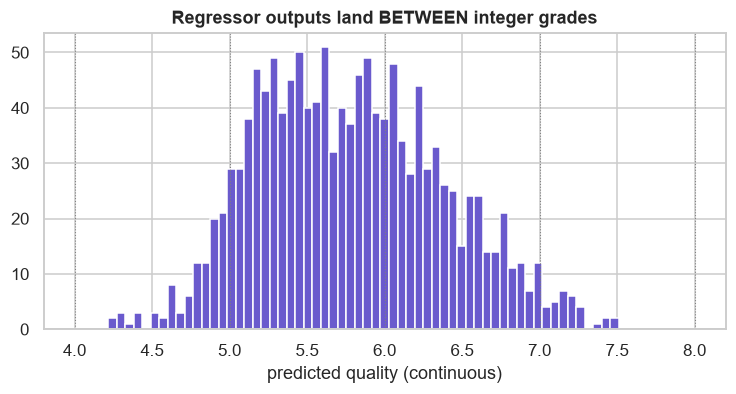

classification QWK 0.494  ->  regression+round QWK 0.525


In [2]:
clf = LGBMClassifier(**LG).fit(Xtr, ytr); results["classification"] = M.report(yte, clf.predict(Xte), "classification")
reg = LGBMRegressor(**LG).fit(Xtr, ytr); raw_pred = reg.predict(Xte)
results["regression+round"] = M.report(yte, raw_pred, "regression+round")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(raw_pred, bins=60, color="slateblue"); [ax.axvline(g, color="grey", ls=":", lw=.7) for g in range(4,9)]
ax.set_title("Regressor outputs land BETWEEN integer grades"); ax.set_xlabel("predicted quality (continuous)")
eda.savefig(fig, "p6_regpred.png"); plt.show()
print("classification QWK %.3f  ->  regression+round QWK %.3f" % (results["classification"].QWK, results["regression+round"].QWK))

### 2. The optimized rounder

Rounding at the half-integers (.5) assumes the grades are symmetric and equally likely — but they
aren't. `modeling.OptimizedRounder` searches for the **cut points** that maximise QWK on the training
predictions. The learned cuts come out **asymmetric** — the 8→9 boundary is pushed up near 8.6 because
grade 9 is so rare that you should almost never predict it. This lifts test QWK again, for free.

learned cut points: [3.61 4.75 5.54 6.38 7.19 8.59]   (naive would be 3.5 .. 8.5)


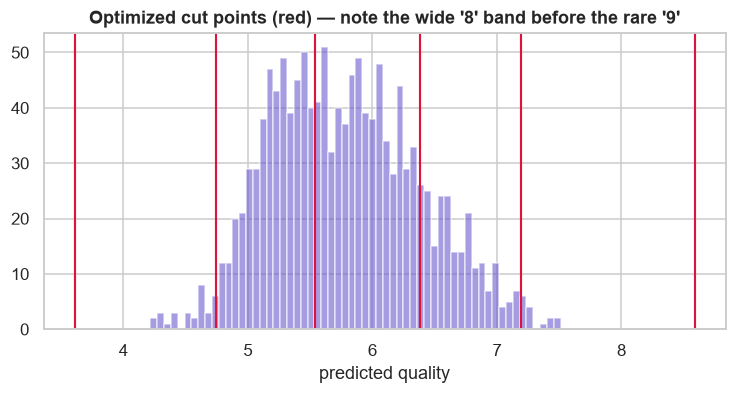

regression+round QWK 0.525  ->  +optimized rounder QWK 0.563


In [3]:
rnd = M.OptimizedRounder().fit(reg.predict(Xtr), ytr)
results["regression+optimized"] = M.report(yte, rnd.predict(raw_pred), "regression+optimized")
print("learned cut points:", np.round(np.sort(rnd.cuts_), 2), "  (naive would be 3.5 .. 8.5)")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(raw_pred, bins=60, color="slateblue", alpha=.6)
for c in np.sort(rnd.cuts_): ax.axvline(c, color="crimson", lw=1.4)
ax.set_title("Optimized cut points (red) — note the wide '8' band before the rare '9'"); ax.set_xlabel("predicted quality")
eda.savefig(fig, "p6_optcuts.png"); plt.show()
print("regression+round QWK %.3f  ->  +optimized rounder QWK %.3f" % (results["regression+round"].QWK, results["regression+optimized"].QWK))

### 3. Ordinal regression — Frank & Hall

The proper ordinal approach: instead of one 7-way problem, solve **K−1 = 6 binary problems** — "is
quality > 3?", "> 4?", … "> 8?". Each is a clean, well-balanced classifier. Their cumulative
probabilities reconstruct the full grade distribution P(quality = g), from which we take the
**expected grade**. This uses the order *without* assuming the grades are evenly spaced — the
theoretically "right" framing.

In [4]:
grades = M.LABELS
prob_gt = {k: LGBMClassifier(**LG).fit(Xtr, (ytr > k).astype(int)).predict_proba(Xte)[:, 1] for k in grades[:-1]}
pmf = np.zeros((len(Xte), len(grades))); prev = np.ones(len(Xte))
for i, g in enumerate(grades):
    p_gt = prob_gt.get(g, np.zeros(len(Xte)))   # P(y>g); 0 for the top grade
    pmf[:, i] = prev - p_gt; prev = p_gt
exp_grade = (pmf * grades).sum(1)
results["ordinal (Frank-Hall)"] = M.report(yte, exp_grade, "ordinal (Frank-Hall)")
print("Frank-Hall ordinal QWK %.3f" % results["ordinal (Frank-Hall)"].QWK)
print("example reconstructed P(quality=g) for one wine:", dict(zip(grades, pmf[0].round(2))))

Frank-Hall ordinal QWK 0.533
example reconstructed P(quality=g) for one wine: {np.int64(3): np.float64(0.0), np.int64(4): np.float64(0.0), np.int64(5): np.float64(0.12), np.int64(6): np.float64(0.87), np.int64(7): np.float64(0.0), np.int64(8): np.float64(-0.0), np.int64(9): np.float64(0.0)}


### 4. Head-to-head

All four framings, same model, same split. **Regression with an optimized rounder wins** — and the
spread from worst (classification) to best is ~0.07 QWK, *larger than the gap between LightGBM and
logistic in Part 5*. Framing is a first-class modelling decision, not an afterthought.

                      accuracy  macro_F1    MAE    QWK
classification           0.550     0.262  0.505  0.494
regression+round         0.549     0.252  0.495  0.525
regression+optimized     0.547     0.300  0.499  0.563
ordinal (Frank-Hall)     0.556     0.255  0.484  0.533


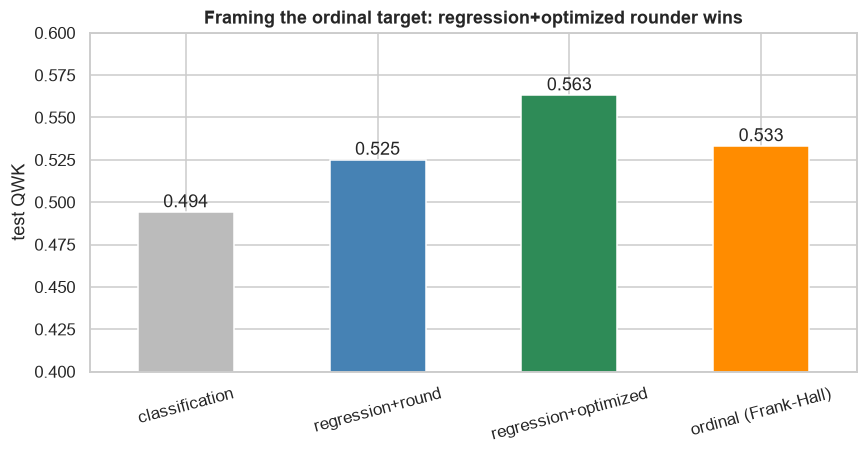


best framing: regression+optimized (QWK 0.563)


In [5]:
board = pd.DataFrame(results.values())
print(board.to_string())
fig, ax = plt.subplots(figsize=(9, 4))
board["QWK"].plot.bar(ax=ax, color=["#bbb","steelblue","seagreen","darkorange"], rot=15)
ax.set_ylabel("test QWK"); ax.set_ylim(0.4, 0.6); ax.set_title("Framing the ordinal target: regression+optimized rounder wins")
for i, v in enumerate(board["QWK"]): ax.text(i, v+.003, f"{v:.3f}", ha="center")
eda.savefig(fig, "p6_framings.png"); plt.show()
print("\nbest framing: %s (QWK %.3f)" % (board.QWK.idxmax(), board.QWK.max()))

### Takeaways

- **Regression beats classification** for this ordinal target (QWK 0.53 vs 0.49) — predicting a
  *number* respects that far misses are worse, which classification ignores.
- The **optimized rounder** adds more (→ ~0.56) by learning **asymmetric cut points** that account for
  the imbalance (you should rarely commit to a 9).
- **Frank–Hall ordinal** (K−1 binary models) also beats classification and is the most principled
  framing — it encodes order without assuming equal spacing.
- **Framing > model**: the QWK spread across framings exceeds the spread across algorithms. Decide how
  to *pose* an ordinal problem before tuning the learner.

**Next — Part 7 (Class imbalance):** the tails are still being ignored. Can class weights or
resampling (SMOTE) rescue the rare grades — and what does it cost the overall QWK?